# Guider plots

What each plot in `pfs.drp.qa.guiders.plotting` shows, where its data come from, how to read it and what to look
for, with a sample of each. Run it top to bottom to see them on other data, or after changing a plot:

```
jupyter nbconvert --to notebook --execute --inplace docs/guider-plots.ipynb
```

By default it reads the AG data the tests use: engineering visits of Run 30 (2026-08-31), trimmed to a few guide
stars per camera, in `tests/guiders/data`. On these samples, numbered marks point at the features each section
explains. [Use real data](#Use-real-data) says how to read the opdb instead. For the drp_stella calls these
replace, see [`guiders-migration.ipynb`](guiders-migration.ipynb).

Offsets are a star's measured center minus a reference position, in microns; positions are in hardware coordinates
(`pfs.drp.qa.guiders.coordinates`). **1 AG pixel is 13 µm, or 0.14 arcsec.**

Contents: [Use real data](#Use-real-data) · [showAgcErrorsForVisits](#Guide-error-of-each-AG-exposure) ·
[showAgcErrorsForVisitsByCamera](#Each-camera's-guide-errors,-relative-to-the-others) ·
[showGuiderErrors](#The-guide-stars-on-the-PFI) · [showGuiderErrorsByParams](#Coloured-by-other-quantities) ·
[showTelescopeErrors](#The-guide-corrections-sent-to-the-telescope) · [plotDriftRate](#The-drift-of-the-guide-stars) ·
[plotGuideErrors](#Each-camera's-guide-errors-on-the-PFI) ·
[plotPfsUtilsComparison](#The-guide-stars'-positions:-the-guider's-and-pfs_utils's) ·
[plotFocus](#Focus-from-the-AG-cameras) · [plotFocusByAG](#Each-camera's-focus-relative-to-the-others) ·
[your own figures](#Drawing-into-your-own-figure,-and-redrawing-in-place)

In [1]:
%matplotlib inline
# %matplotlib widget  # for the cursor readout and plotFocus's click-to-set-M2_OFF3 (needs ipympl)

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pfs.drp.qa.guiders import analysis, coordinates, plotting, queries

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["figure.dpi"] = 72


def mark(ax, n, xy, data=False):
    """Mark a feature of a sample plot with its number, at ``xy``, a fraction of the panel, or data coordinates if ``data``."""
    ax.annotate(
        str(n),
        xy=xy,
        xycoords="data" if data else "axes fraction",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        bbox={"boxstyle": "circle,pad=0.25", "facecolor": "black", "edgecolor": "white", "alpha": 0.85},
        zorder=100,
        annotation_clip=False,
    )

## Use real data

The samples below are the tests' AG data. To use real data, set `USE_OPDB = True`, give an `OpDB` (the read-only
user) and the visits, and run the notebook from the top. With a Gen3 butler holding the visits' raws, the readers
also fill `inst_pa` from the raw headers and, for visits before 2025-03-21, `m2_off3` from `W_M2OFF3`. The numbered
marks, placed for the samples, are then left off. Science visits are proprietary: keep their plots within the team.

On real data the second cell also runs the readers and fits the plots below don't use, and prints a check of each,
so one run tests the whole of `pfs.drp.qa.guiders`. The default visits are about 98,500 rows (a minute or two).

| Sample | Visits | What |
|---|---|---|
| `focusSweep` | 148266, 148270–148277 | M2_OFF3 from 2.725 to 3.55 mm |
| `raster` | 148284–148292 | a raster scan of seven pointings, a flux uniformity exposure, the start of a second scan |
| `allSky` | 148258 | a 900 s exposure |

In [2]:
USE_OPDB = False
SAMPLE = not USE_OPDB  # mark the samples' features

VISITS = {
    "focusSweep": [148266, *range(148270, 148278)],
    "raster": list(range(148284, 148293)),
    "allSky": [148258],
}

if USE_OPDB:
    from pfs.utils.database.opdb import OpDB

    opdb = OpDB(host="pfsa-db", user="public_user")  # the read-only user
    butler = None  # a Gen3 butler with the visits' raws: INST-PA, and M2_OFF3 before 2025-03-21
    EARLY_VISIT = None  # a visit before 2025-03-21, to check M2_OFF3 from W_M2OFF3 (needs the butler)

    focusSweep, raster, allSky = (queries.readAgcData(opdb, VISITS[name], butler=butler) for name in VISITS)
    allSkyVisit = VISITS["allSky"][0]
    allSkyDesign = queries.readPfsDesign(opdb, allSkyVisit).pfs_design_id.iloc[0]
    allSkyStars = queries.readAGCStars(opdb, allSkyDesign, allSkyVisit)
else:
    DATA = Path("../tests/guiders/data")
    focusSweep, raster, allSky = (pd.read_parquet(DATA / f"agcData-{name}.parquet") for name in VISITS)
    allSkyStars = (
        pd.read_parquet(DATA / "agcStars.parquet").query("pfs_visit_id == 148258").reset_index(drop=True)
    )

In [3]:
if USE_OPDB:
    # What was read.
    for name, data in [("focusSweep", focusSweep), ("raster", raster), ("allSky", allSky)]:
        valid = analysis.selectValidMatches(data).mean()
        print(
            f"readAgcData {name}: {len(data)} rows, {data.agc_exposure_id.nunique()} AG exposures, {valid:.0%} valid"
            f" matches; m2_off3 missing in {data.m2_off3.isna().mean():.0%} of rows;"
            f" inst_pa {'read' if data.inst_pa.notna().any() else 'not read (no butler)'}"
        )
    print(f"readAGCStars: {len(allSkyStars)} guide stars of design {allSkyDesign:#x}")

    # The readers the plots don't use.
    telStatus = queries.readTelStatus(opdb, VISITS["allSky"])
    print(f"readTelStatus: {len(telStatus)} rows for visit {allSkyVisit}")
    spsInfo = queries.readSpSInfo(
        opdb, taken_after="2026-08-31 18:00", exp_type=None, limit=500
    )  # HST; rows, not visits
    print(f"readSpSInfo: {spsInfo.pfs_visit_id.nunique()} visits from 2026-08-31 18:00 HST")

    # The fits the plots don't use.
    globalFit = analysis.fitGlobalModel(raster, fitAgcOffsets=True)
    valid = analysis.selectValidMatches(globalFit.agcData)
    residual = np.hypot(globalFit.agcData.dx_model_um, globalFit.agcData.dy_model_um)[valid]
    print(f"fitGlobalModel: median residual {residual.median():.1f} µm; camera terms:")
    display(globalFit.cameras.round(1))
    valid = analysis.selectValidMatches(allSky)  # smoothAgcData smooths these, and leaves the others alone
    offsets = [
        coordinates.addOffsets(d[valid]).dx_nominal_um.std()
        for d in (allSky, analysis.smoothAgcData(allSky, 5))
    ]
    print(
        f"smoothAgcData: x offsets' scatter {offsets[0]:.1f} µm, smoothed over 5 AG exposures {offsets[1]:.1f} µm"
    )

    # The butler.
    if butler is not None:
        print("readInstPa:", queries.readInstPa(butler, VISITS["allSky"]).to_dict())
        if EARLY_VISIT is not None:
            early = queries.readAgcData(opdb, [EARLY_VISIT], butler=butler)
            print(
                f"W_M2OFF3 of {EARLY_VISIT}: m2_off3 {early.m2_off3.min():.3f}-{early.m2_off3.max():.3f} mm"
            )

## Guide error of each AG exposure

The mean offset of the guide stars from where the guider expected them, center minus nominal, in each AG exposure: its length r, and its x and y in hardware coordinates (µm). This is what the guider tries to keep at 0.

**Data.** readAgcData: agc_match's agc_center_[xy]_mm and agc_nominal_[xy]_mm of the valid matches (agc_match.flags GOOD_MATCH); agc_exposure.taken_at; shutter_open from the sps_exposure times.

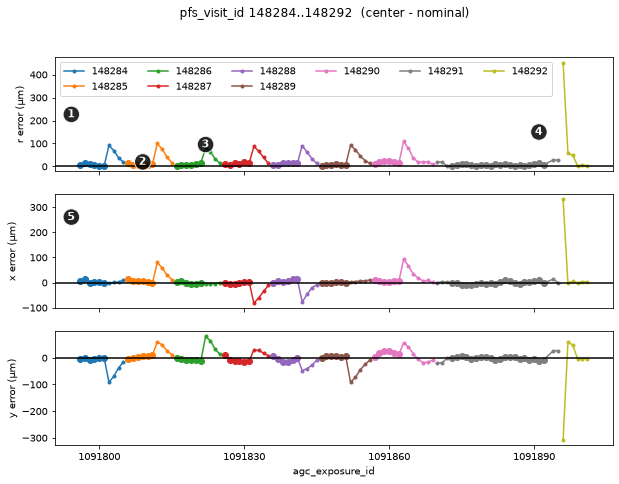

In [4]:
plot = plotting.showAgcErrorsForVisits(raster)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.03, 0.5))
    mark(plot.axes[0, 0], 2, (1091809, 19.9134), data=True)
    mark(plot.axes[0, 0], 3, (1091822, 95.3754), data=True)
    mark(plot.axes[0, 0], 4, (1091891, 150), data=True)
    mark(plot.axes[1, 0], 5, (0.03, 0.8))

**Reading it.**

1. Each visit has its own colour; its legend is on the top panel.
2. Large dots: AG exposures taken while the spectrograph shutters were open. These are the ones that matter for the science.
3. A jump after the shutters close: in a raster scan the telescope moves to the next position, and the guider takes about 40 s to catch up.
4. 148292, the start of the second scan, has no SpS exposure (shutter_open 2). Its first errors are hundreds of microns, as the guider starts on a new pointing.
5. x and y show the direction of the error, in hardware coordinates.

**Look for.**

- r within a few microns (1 AG pixel is 13 µm) while the shutters are open.
- Spikes, or errors that persist through a visit: the guider isn't correcting.
- A slow trend in x or y: a drift the guider follows late.

**Options.** byTime (HST on the x axis), yLimit_um, reference (e.g. boresight), pfsVisitIds and agcExposureIds. ics_pfsPlotActor draws it on its own three axes (axes=).

*Sample:* Raster scan, visits 148284-148292.

Against the time (HST), from the boresight rather than the nominal positions; `plot.data` holds the values plotted.

,agc_exposure_id,pfs_visit_id,taken_at,shutter_open,dx_um,dy_um,dr_um
0,1091796,148284,2026-08-31 23:43:41.085297,1,4.231786,-8.453508,9.453560
1,1091797,148284,2026-08-31 23:43:51.105842,1,12.573071,-7.301710,14.539501
2,1091798,148284,2026-08-31 23:44:01.080298,1,-1.750714,-15.491179,15.589792
3,1091799,148284,2026-08-31 23:44:11.088201,1,1.523929,-11.654363,11.753575
4,1091800,148284,2026-08-31 23:44:21.071724,1,1.313714,-6.611763,6.741013


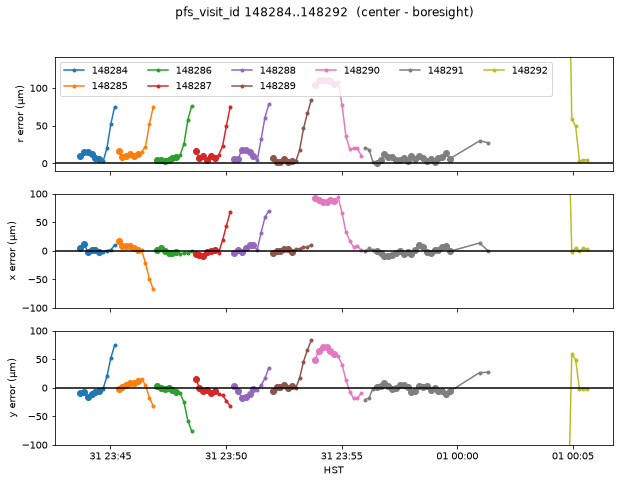

In [5]:
plot = plotting.showAgcErrorsForVisits(raster, byTime=True, reference="boresight", yLimit_um=100)
plot.data.head()

## Each camera's guide errors, relative to the others

Each camera's mean offset in each AG exposure (center minus nominal), less the camera's median, as the cameras' positions aren't known well, and less the exposure's mean over the cameras, which is the telescope's pointing error. What is left is how the cameras move relative to each other.

**Data.** readAgcData: valid matches without bad detection flags, taken while the shutters weren't closed. With fitPfiModel, offsets are from analysis.fitGlobalModel's model instead of the nominal positions.

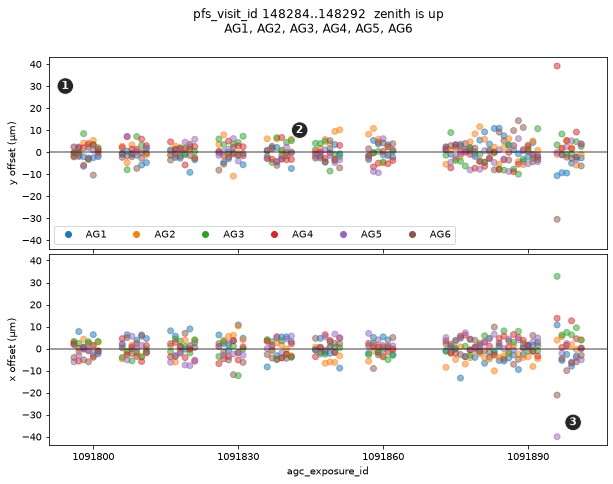

In [6]:
plot = plotting.showAgcErrorsForVisitsByCamera(raster)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.03, 0.85))
    mark(plot.axes[0, 0], 2, (0.45, 0.62))
    mark(plot.axes[1, 0], 3, (0.94, 0.12))

**Reading it.**

1. y points towards the zenith (rotateToZenith), x towards the Opt side.
2. Each point is one camera in one AG exposure, less the camera's median and the exposure's mean over the cameras: what is left is how the cameras move relative to each other.
3. Outliers: a camera with one badly measured star, or a camera that moved.

**Look for.**

- Scatter of a few microns about 0.
- Trends with altitude or rotator angle (plotBy): flexure.
- Opposite cameras with opposite signs: a rotation or scale left in (try fitPfiModel).
- One camera apart from the others: that camera, or its stars.

**Options.** plotBy (agc_exposure_id, altitude, insrot), colorBy (camera, visit, altitude, insrot), plotPerCamera, showAltInsrot (mean offsets binned by altitude and rotator angle), plotDzDfocus (against the AG actor's focus error), drawVisitBoundaries, rotateToZenith.

*Sample:* Raster scan, visits 148284-148292.

One panel per camera, against altitude, coloured by visit.

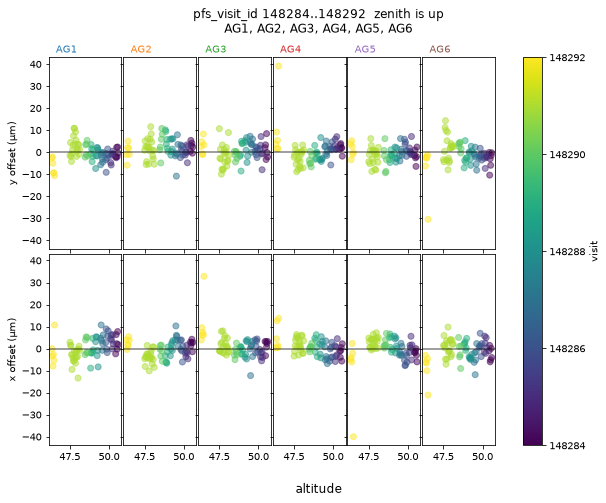

In [7]:
plot = plotting.showAgcErrorsForVisitsByCamera(raster, plotBy="altitude", colorBy="visit", plotPerCamera=True)

### y against x

The same offsets as above, y against x: each AG exposure, or with plotXYStride=None each visit.

**Data.** As above.

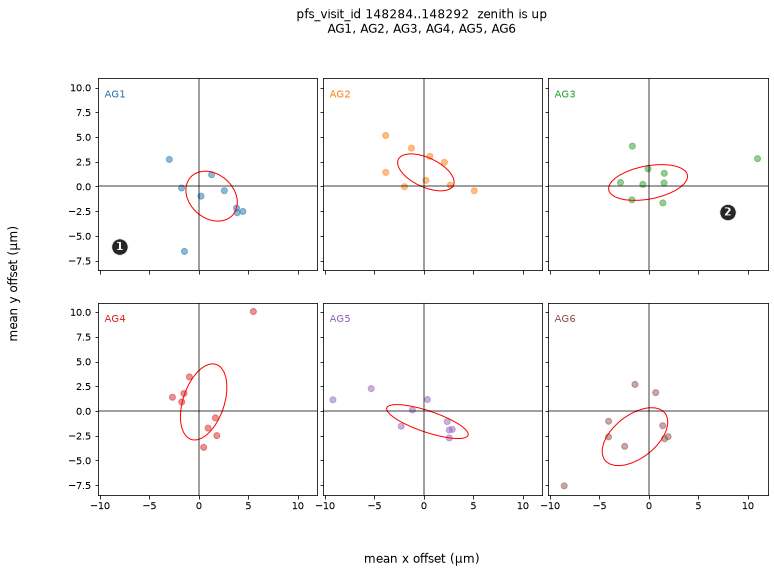

In [8]:
plot = plotting.showAgcErrorsForVisitsByCamera(
    raster,
    plotXY=True,
    plotPerCamera=True,
    plotXYStride=None,
    showCovariance=True,
    fig=plt.figure(figsize=(12, 8)),
)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.1, 0.12))
    mark(plot.axes[0, 2], 2, (0.82, 0.3))

**Reading it.**

1. One panel per camera; each point is the camera's mean offset in one visit.
2. The red ellipse holds 1 sigma of the points (clipped second moments). A long ellipse means the camera moves along one direction, e.g. flexure towards the zenith.

**Look for.**

- Points clustered on 0.
- Long ellipses: motion along one direction, such as flexure towards the zenith.
- Clusters away from 0 for some visits: the cameras moved between visits.

**Options.** connectDxDy joins the points in order; nVisitMin drops visits with few AG exposures.

*Sample:* Raster scan, visits 148284-148292; one point per visit.

## The guide stars on the PFI

Each AG camera at its position on the PFI (mm), and each guide star at its offset from where the guider's models put it (µm, so magnified 1000 times) about the camera. With the models off, as in ics_pfsPlotActor, that is the offset from the guider's nominal position; with modelBoresightOffset and modelCCDOffset, what is left after an offset, rotation and scale of each exposure and of each camera.

**Data.** analysis.fitGuiderModel on readAgcData. The stars plotted are those the fit selected: valid matches without bad detection flags, shutters open, in AG exposures whose guide error passes maxGuideError_um.

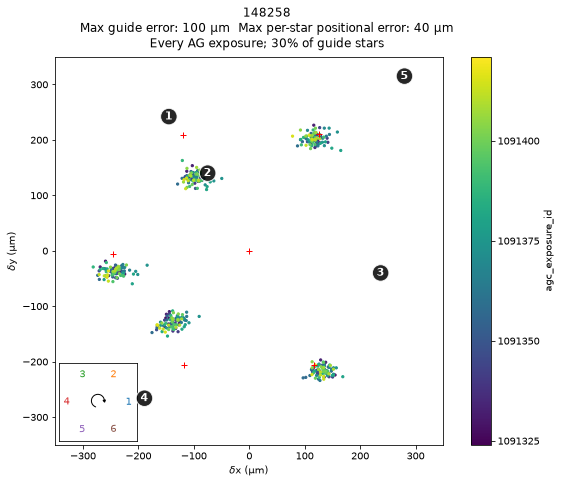

In [9]:
actorFit = analysis.GuiderFitConfig(modelBoresightOffset=False, modelCCDOffset=False, maxGuideError_um=100)
actorPlot = plotting.GuiderPlotConfig(guideStarFrac=0.3)

plot = plotting.showGuiderErrors(analysis.fitGuiderModel(allSky, actorFit), actorPlot)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (-145, 242), data=True)
    mark(plot.axes[0, 0], 2, (-75, 140), data=True)
    mark(plot.axes[0, 0], 3, (237, -40), data=True)
    mark(plot.axes[0, 0], 4, (0.23, 0.12))
    mark(plot.axes[0, 0], 5, (0.9, 0.95))

**Reading it.**

1. +: the mean position of the camera's stars (mm). Each star is drawn at its offset from where the guider expected it (µm) from there.
2. A cloud off its +: the camera's stars are systematically away from where the guider expected them; here AG3 and AG5 by about 80 µm. Without the models these offsets mix the boresight's offset, rotation and scale with each camera's own.
3. No AG1 stars: none of its matches in 148258 was valid.
4. The cartoon: where the cameras are, and the sense of the rotator.
5. Colour: the AG exposure, so the time.

**Look for.**

- Clouds centred on their +, a few tens of microns across.
- Clouds off their + in a pattern round the ring: tangential is a rotation, radial a scale.
- Colour changing across a cloud: the stars drift during the visit.
- A missing camera: none of its matches is valid.

**Options.** GuiderPlotConfig: showGuideStarsAsArrows, showAverageGuideStarPos and Path (each camera's mean per exposure), rotateToAG1Down (minus the rotator angle), showGuideStarPositions, guideStarFrac. colorbars= updates the colorbar when redrawing (ics_pfsPlotActor).

*Sample:* All-sky exposure 148258 with ics_pfsPlotActor's settings: no models, guide error under 100 µm, 30% of the guide stars.

With the boresight and camera models (the defaults) on the raster scan, as arrows; then rotated by minus the
rotator angle, with each camera's mean offset per exposure and its path. The fitted transforms are in the fit:
`fit.exposureParameters`, `fit.cameraParameters`.

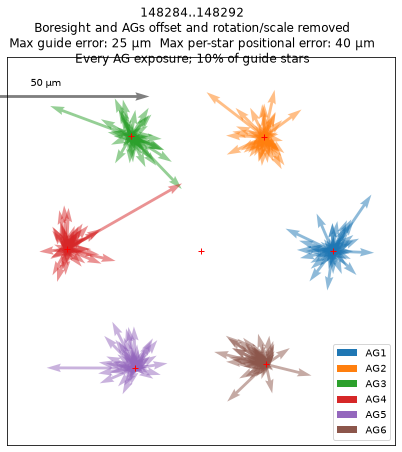

In [10]:
fit = analysis.fitGuiderModel(raster)
plot = plotting.showGuiderErrors(
    fit, plotting.GuiderPlotConfig(showGuideStarsAsPoints=False, showGuideStarsAsArrows=True)
)

,x0_mm,y0_mm,theta_deg,dscale,scale2_per_mm2
agc_camera_id,,,,,
0,0.008554,0.004631,0.000001,4.991292e-08,0.0
1,0.006705,-0.005799,-0.000054,-4.762698e-07,0.0
2,-0.002768,-0.000602,0.000002,-6.390961e-08,0.0
3,-0.002208,-0.002387,0.000005,3.420924e-08,0.0
4,-0.000339,0.000020,0.000011,9.122215e-08,0.0
5,-0.002681,0.003427,-0.000004,-2.851277e-09,0.0


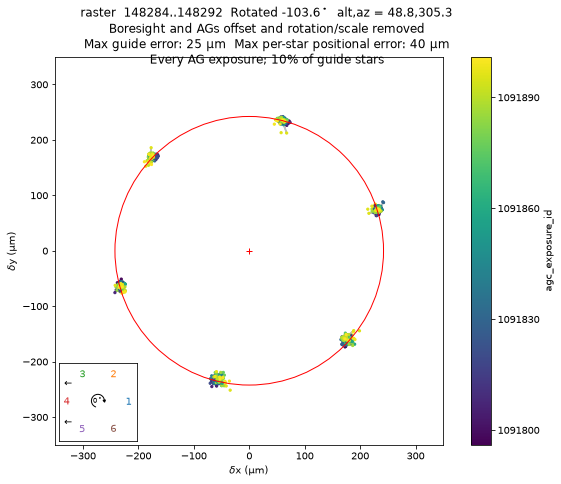

In [11]:
config = plotting.GuiderPlotConfig(
    rotateToAG1Down=True, showAverageGuideStarPos=True, showAverageGuideStarPath=True
)
plot = plotting.showGuiderErrors(fit, config, name="raster")
fit.cameraParameters

## Coloured by other quantities

Each camera's mean offset in each AG exposure, drawn as showGuiderErrors draws them, once per quantity and coloured by it.

**Data.** GuiderFit.guideErrorByCamera from analysis.fitGuiderModel, and the quantities from its agcData.

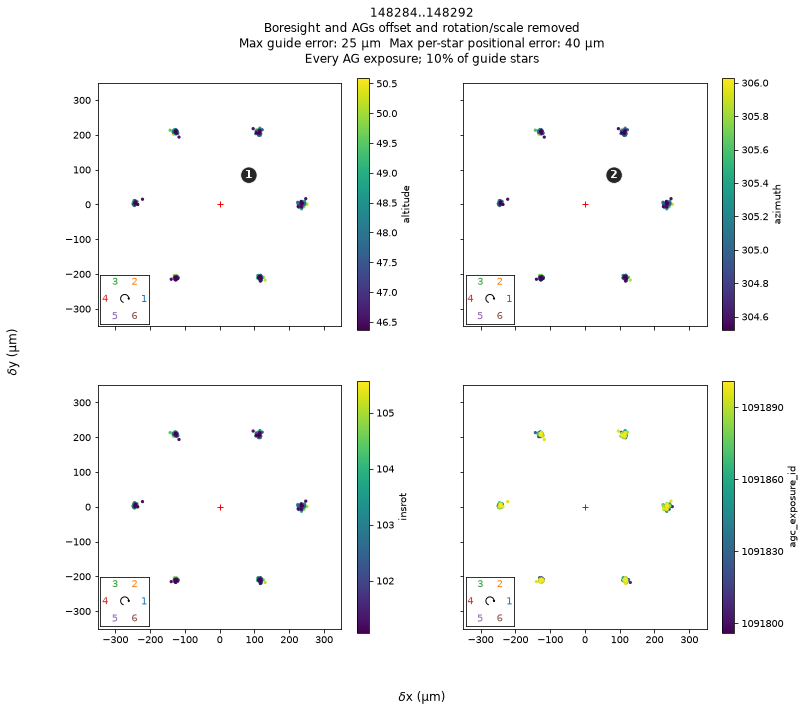

In [12]:
plot = plotting.showGuiderErrorsByParams(
    fit, ["altitude", "azimuth", "insrot", "agc_exposure_id"], fig=plt.figure(figsize=(12, 10))
)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.62, 0.62))
    mark(plot.axes[0, 1], 2, (0.62, 0.62))

**Reading it.**

1. Each point is one camera's mean offset in one AG exposure, coloured by the quantity of the panel.
2. A colour gradient across a cloud: the offsets follow that quantity.

**Look for.**

- Colour gradients along a cloud: offsets that follow altitude, rotator angle, time...

*Sample:* Raster scan, visits 148284-148292, with the boresight and camera models.

## The guide corrections sent to the telescope

The corrections the AG actor sent the telescope after each AG exposure with the shutters open: altitude and azimuth (arcsec) and rotator angle.

**Data.** readAgcData: agc_guide_offset's guide_delta_el, guide_delta_az and guide_delta_insrot (arcsec).

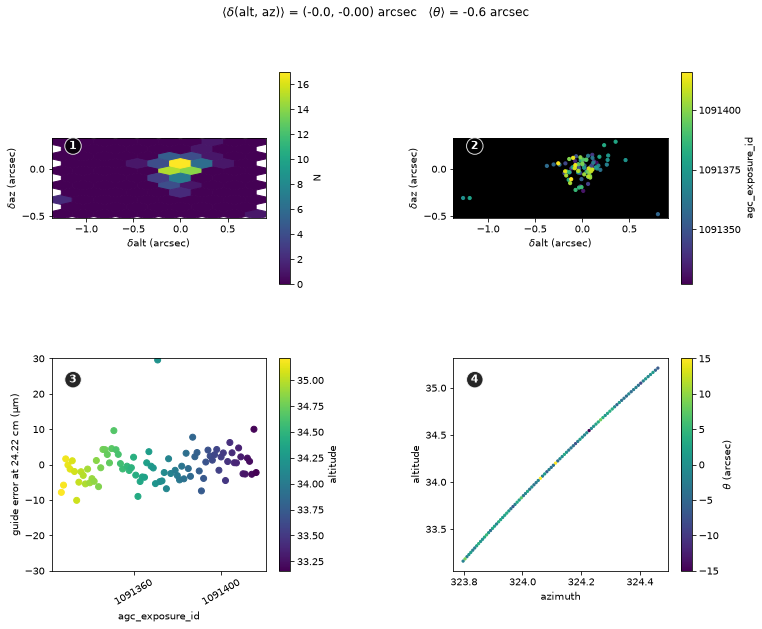

In [13]:
plot = plotting.showTelescopeErrors(allSky, fig=plt.figure(figsize=(12, 9)))
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.1, 0.9))
    mark(plot.axes[0, 1], 2, (0.1, 0.9))
    mark(plot.axes[1, 0], 3, (0.1, 0.9))
    mark(plot.axes[1, 1], 4, (0.1, 0.9))

**Reading it.**

1. How often the AG actor sent each altitude and azimuth correction.
2. The same corrections, coloured by AG exposure: their order in time.
3. The rotator correction, as the motion it makes at the AG cameras (24 cm from the axis).
4. The rotator correction by azimuth and altitude.

**Look for.**

- Corrections centred on 0, of a few tenths of an arcsec.
- Corrections that keep one sign, or trend in time: tracking or pointing model errors.
- Large rotator corrections: a rotator or position angle error.

**Options.** showTheta: the rotator correction in arcsec, rather than microns at the AG cameras.

*Sample:* All-sky exposure 148258.

## The drift of the guide stars

The guide stars' offsets against time, split into radial and tangential components, with the fitted drift rates.

**Data.** analysis.fitDriftRate on readAgcData: valid matches with the shutters open, center minus nominal by default, averaged per camera and AG exposure, less each camera's mean.

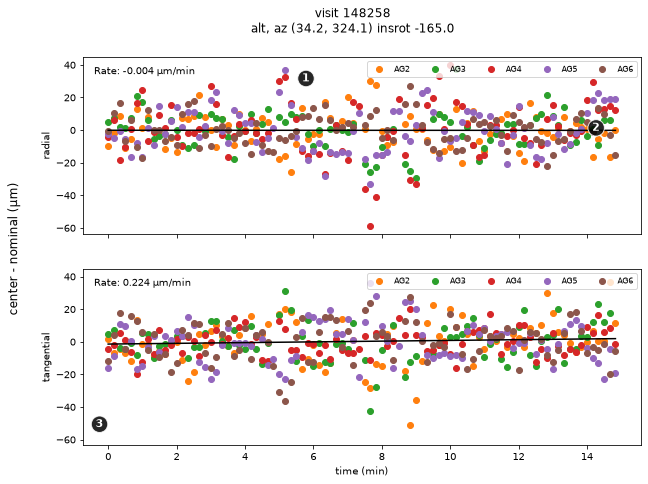

In [14]:
drift = analysis.fitDriftRate(allSky)
plot = plotting.plotDriftRate(drift)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.4, 0.88))
    mark(plot.axes[0, 0], 2, (0.92, 0.6))
    mark(plot.axes[1, 0], 3, (0.03, 0.12))

**Reading it.**

1. Each point: one camera's mean offset in one AG exposure, less the camera's mean.
2. The fitted line; its slope is the rate.
3. Radial: away from the boresight. Tangential: anticlockwise round it.

**Look for.**

- Rates within a fraction of a micron per minute.
- A radial drift with one sign on every camera: a scale change (focus, temperature).
- A tangential drift: a rotation.

**Options.** byTime=False plots against agc_exposure_id; fitDriftRate(radialTangential=False) gives x and y.

*Sample:* All-sky exposure 148258: -0.004 µm/min radial, 0.22 µm/min tangential.

In [15]:
drift.rates

radial_rate_um_per_min            -0.004255
radial_offset_um                  -0.111566
tangential_rate_um_per_min         0.224373
tangential_offset_um              -1.420134
pfs_visit_id                  148258.000000
altitude                          34.187591
azimuth                          324.116265
insrot                          -165.009036
exptime                          900.019501
Name: 148258, dtype: float64

## Each camera's guide errors on the PFI

Each camera's mean offset in each AG exposure (or visit) from a reference position, drawn about the camera's position, and their mean over the cameras about the boresight. drp_stella's estimateGuideErrors(plot=True).

**Data.** analysis.estimateGuideErrors on readAgcData: valid matches, center minus a reference: center0 (each star's median position over the data), nominal, boresight...

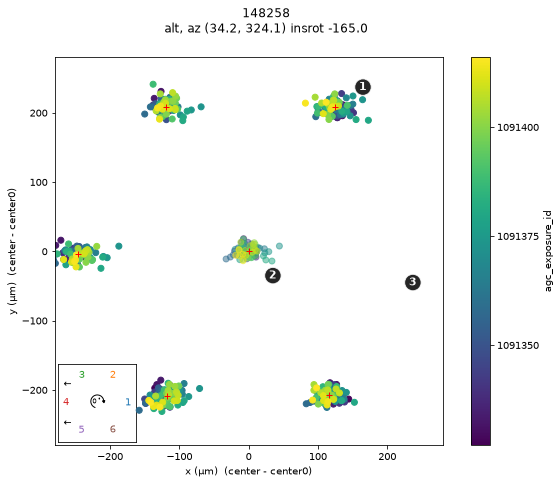

In [16]:
plot = plotting.plotGuideErrors(analysis.estimateGuideErrors(allSky))
if SAMPLE:
    mark(plot.axes[0, 0], 1, (165, 237), data=True)
    mark(plot.axes[0, 0], 2, (35, -35), data=True)
    mark(plot.axes[0, 0], 3, (237, -45), data=True)

**Reading it.**

1. Each camera's mean offset (µm) in each AG exposure, about the camera's median position (mm, red +). Here a tight cluster, a few microns across.
2. The mean over the cameras, about the boresight.
3. No AG1 points: none of its matches in 148258 was valid. In a raster scan, each camera's points trace the scan instead.

**Look for.**

- Each camera's points in a tight cluster.
- The same pattern on every camera: the telescope moved (in a raster scan, for instance).
- Patterns that turn round the ring: a rotation.

**Options.** colorBy (agc_exposure_id, pfs_visit_id, time), drawTrack, rotateToAG1Down, expand; showClosedShutter adds the closed-shutter AG exposures, as small dots, given estimateGuideErrors(includeClosedShutter=True).

*Sample:* All-sky exposure 148258, from each star's median position (center0).

The raster scan, with the AG exposures taken with the shutters closed (small dots) and each camera's track: each
camera's points trace the scan.

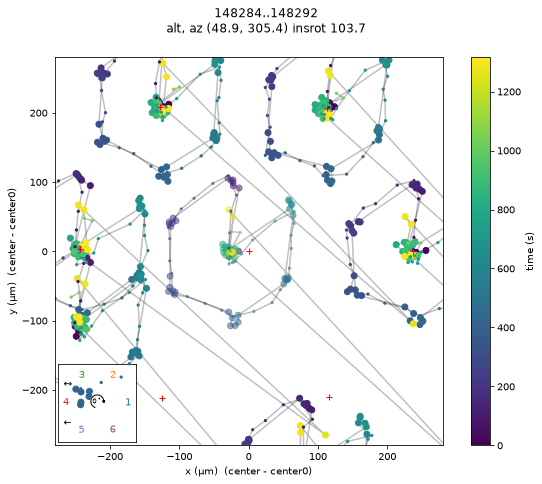

In [17]:
guideErrors = analysis.estimateGuideErrors(raster, includeClosedShutter=True)
plot = plotting.plotGuideErrors(guideErrors, showClosedShutter=True, drawTrack=True, colorBy="time")

## The guide stars' positions: the guider's and pfs_utils's

Where the guider expected each guide star (agc_nominal), and where pfs_utils puts it with the AG actor's model and inputs, about each camera.

**Data.** readAGCStars (the design's guide stars) and readAgcData (the AG actor's field center, position angle, ADC and M2 positions, and detector half); medians over the visit's first 10 AG exposures.

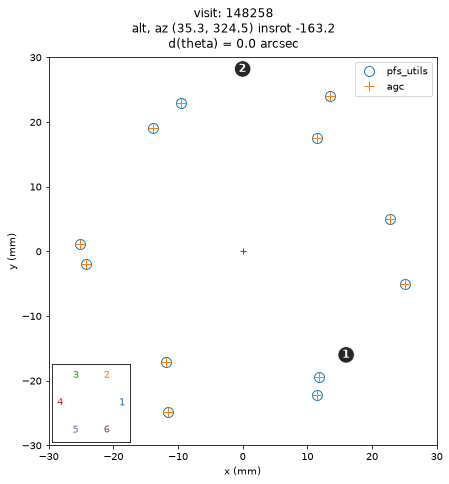

In [18]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # pfs_utils's clamped parallaxes
    comparison = analysis.comparePfsUtilsPositions(allSkyStars, allSky)
plot = plotting.plotPfsUtilsComparison(comparison)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (16, -16), data=True)
    mark(plot.axes[0, 0], 2, (0.5, 0.97))

**Reading it.**

1. Each camera's stars, the cameras drawn 10 times closer to the boresight. The guider's positions (crosses) lie on pfs_utils's (circles).
2. d(theta): the median difference of the stars' angles about the boresight.

**Look for.**

- The two on top of each other: they agree to well under a micron.
- d(theta) near 0.
- Any disagreement: the AG actor and pfs_utils no longer use the same model.

**Options.** alignCenterPosition (in comparePfsUtilsPositions) removes the mean offset; plotUsingScatter.

*Sample:* All-sky exposure 148258.

## Focus from the AG cameras

The glass has been removed from one half of each AG detector, so its two halves focus at different M2_OFF3, and the difference of the stars' sizes on the two halves gives the focus error. Three rows: the AG actor's focus error; the same from the stars' sizes, measured here; and each star's FWHM.

**Data.** readAgcData: agc_guide_offset.guide_delta_z1-6 (the AG actor's), agc_data's second moments and detection flags (RIGHT marks the half), tel_status.m2_off3. Isolated GAIA stars, valid matches. analysis.estimateFocusErrors uses the AG actor's calibration.

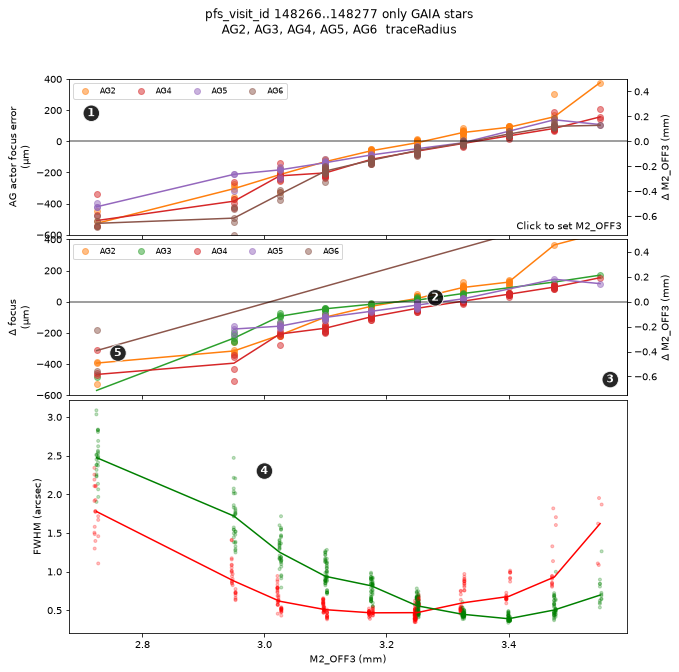

In [19]:
plot = plotting.plotFocus(
    focusSweep, showMedian=True, yLimits_um=(-600, 400), fig=plt.figure(figsize=(10, 10))
)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.04, 0.78))
    mark(plot.axes[1, 0], 2, (3.28, 25), data=True)
    mark(plot.axes[1, 0], 3, (0.97, 0.1))
    mark(plot.axes[2, 0], 4, (3, 2.3), data=True)
    mark(plot.axes[1, 0], 5, (2.76, -330), data=True)

**Reading it.**

1. The AG actor's focus error of each camera (guide_delta_z1-6).
2. The focus error from the stars' sizes on the two halves of each detector. It crosses 0 at best focus, here M2_OFF3 = 3.28 mm.
3. Right axis: the same, as a change of M2_OFF3.
4. Each star's FWHM: red on the left halves, green on the right, with their medians. Each half is sharpest on its own side of best focus.
5. Far from focus the focus error saturates, at about 450 µm. AG6's line is straight: in this trimmed sample it has stars on both halves at only three M2_OFF3.

**Look for.**

- Focus errors crossing 0 at best focus; the AG actor's and ours agreeing.
- Cameras disagreeing about best focus: the focal plane is tilted.
- Each half's FWHM smallest on its own side of best focus.

**Options.** plotBy (focus, agc_exposure_id, altitude, insrot), colorBy, plotPerCamera, averageByFocusPosition, showCameraId, showPfiFocusPosition. Click a panel to set M2_OFF3: the top panel then shows the focus error expected about it (ShowFocusFit).

*Sample:* Focus sweep, visits 148266 and 148270-148277, M2_OFF3 from 2.725 to 3.55 mm.

One column per camera.

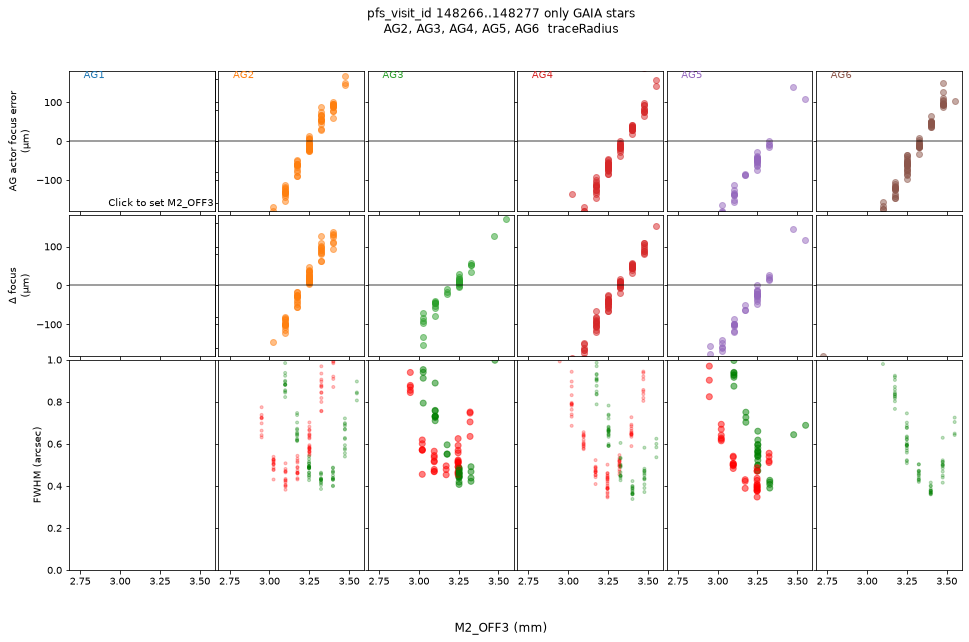

In [20]:
plot = plotting.plotFocus(focusSweep, plotPerCamera=True, fig=plt.figure(figsize=(16, 9)))

### In time

The AG actor's focus error of each camera against AG exposure.

**Data.** As above.

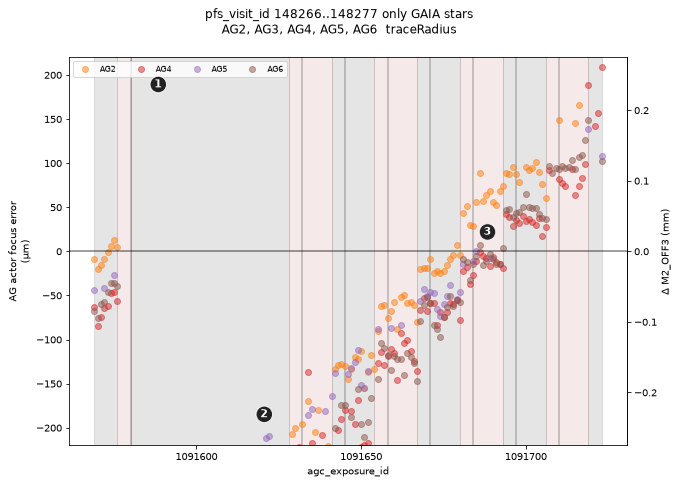

In [21]:
plot = plotting.plotFocus(
    focusSweep,
    plotBy="agc_exposure_id",
    showOpdbFocus=False,
    showFWHM=False,
    showFocusSets=True,
    yLimits_um=220,
)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.16, 0.93))
    mark(plot.axes[0, 0], 2, (0.35, 0.08))
    mark(plot.axes[0, 0], 3, (0.75, 0.55))

**Reading it.**

1. Shading: each run of AG exposures at one M2_OFF3 (showFocusSets).
2. Grey lines: the last AG exposure of each visit. The cursor readout names the visit.
3. The focus error steps with each move of M2_OFF3.

**Look for.**

- A step at each change of M2_OFF3: about 600-700 µm of focus error per mm near focus in Run 30.
- Drifts within a run at one M2_OFF3: the focus changing (temperature, altitude).

*Sample:* Focus sweep, as above; ics_pfsPlotActor's FocusPlot.

## Each camera's focus relative to the others

Each camera's focus error in each visit, less the mean of the other cameras but AG1 (as drp_stella did) and the overall mean, negated to match Kawanomoto-san's plots.

**Data.** analysis.estimateFocusErrors per camera, from the stars' sizes; the median of each visit.

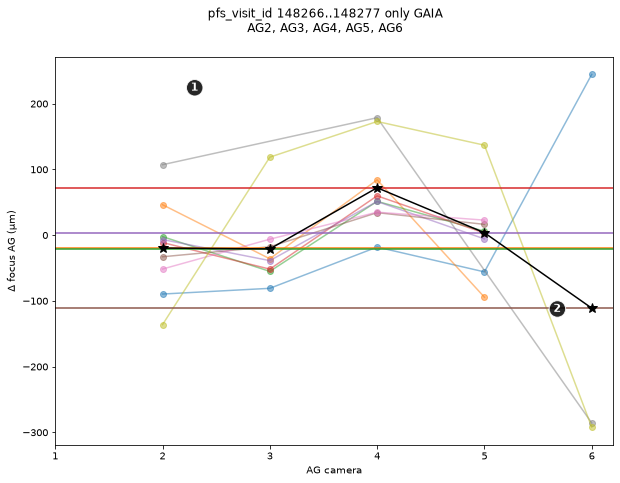

In [22]:
plot = plotting.plotFocusByAG(focusSweep)
if SAMPLE:
    mark(plot.axes[0, 0], 1, (0.25, 0.92))
    mark(plot.axes[0, 0], 2, (0.9, 0.35))

**Reading it.**

1. One line per visit: each camera's focus relative to the others.
2. Black stars, and the horizontal lines: each camera's mean over the visits.

**Look for.**

- The same pattern in every visit: a fixed tilt or piston of the cameras.
- A pattern that changes between visits: the focal plane moving.

**Options.** byCamera=False plots each camera against the visit; byExposureId uses each AG exposure.

*Sample:* Focus sweep, as above.

## Drawing into your own figure, and redrawing in place

Every plot draws on the `ax`, `axes` or `fig` it is given. Here two share a figure, as in ics_pfsPlotActor's
ShowGuiderErrorsCombined: `showAgcErrorsForVisits` in the left column, `showGuiderErrors` on the right. Each titles
its own top panel.

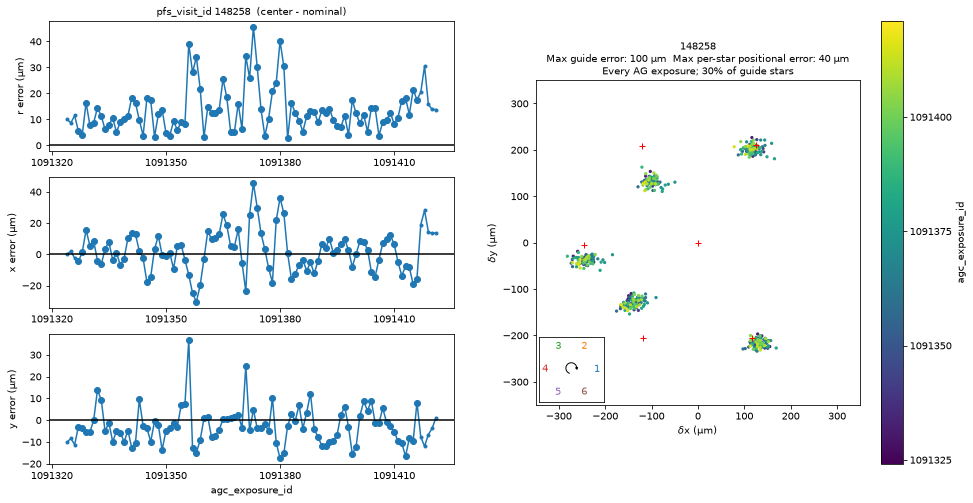

In [23]:
fig = plt.figure(figsize=(16, 8))
grid = fig.add_gridspec(3, 2)
left = [fig.add_subplot(grid[i, 0]) for i in range(3)]
right = fig.add_subplot(grid[:, 1])

plotting.showAgcErrorsForVisits(allSky, axes=left, showLegend=False)
guider = plotting.showGuiderErrors(analysis.fitGuiderModel(allSky, actorFit), actorPlot, ax=right)

To redraw, clear the panels and pass the previous call's `colorbars`: they are updated rather than added again, so
the figure keeps its layout.

5 axes: 4 panels and 1 colorbar


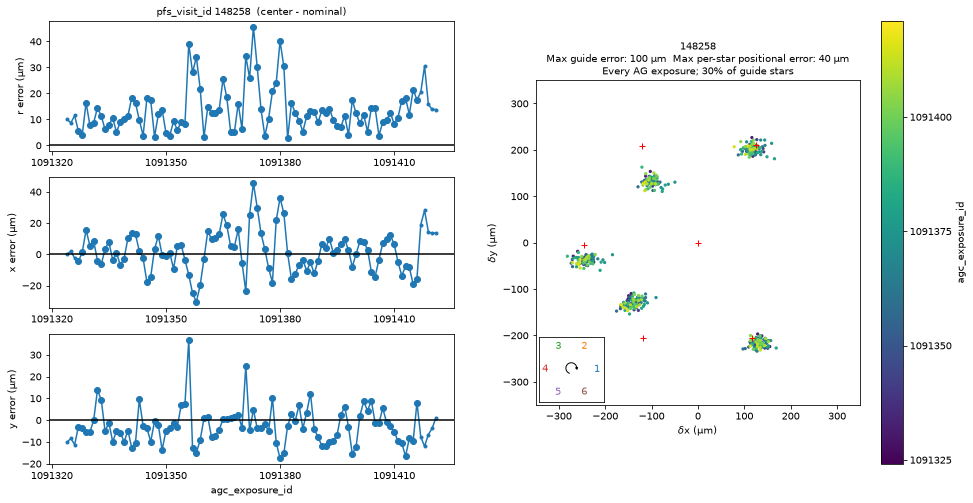

In [24]:
for ax in [*left, right]:
    ax.cla()
plotting.showAgcErrorsForVisits(allSky, axes=left, showLegend=False)
guider = plotting.showGuiderErrors(
    analysis.fitGuiderModel(allSky, actorFit), actorPlot, ax=right, colorbars=guider.colorbars
)
print(f"{len(fig.axes)} axes: 4 panels and 1 colorbar")
fig